<a href="https://colab.research.google.com/github/princeesinha/Housing_Price_Prediction/blob/main/Housing_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving housing_price_prediction_dataset.csv to housing_price_prediction_dataset.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("housing_price_prediction_dataset.csv")
print(df.head())
print(df.shape)
print(df.info())

   Area_sqft  Bedrooms  Bathrooms  House_Age_years  Parking_Spaces  Floor  \
0       3674         5          4                5               0     10   
1       1360         1          1                7               2     10   
2       1794         3          2               14               1      0   
3       1630         4          2               14               1      6   
4       1595         2          2               14               0      1   

   Distance_from_City_km  Location_Score    Price  
0                    0.8               5  1206454  
1                    2.6               4   582795  
2                    7.6               1   405058  
3                   11.8              10   877500  
4                    4.3               3   587633  
(3000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   

In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicated Rows:")
print(df.duplicated().sum())

print("\nStatistics:")
print(df.describe())

Missing Values:
Area_sqft                0
Bedrooms                 0
Bathrooms                0
House_Age_years          0
Parking_Spaces           0
Floor                    0
Distance_from_City_km    0
Location_Score           0
Price                    0
dtype: int64

Duplicated Rows:
0

Statistics:
         Area_sqft     Bedrooms    Bathrooms  House_Age_years  Parking_Spaces  \
count  3000.000000  3000.000000  3000.000000      3000.000000     3000.000000   
mean   2273.049000     3.510333     2.844000        15.065667        1.016333   
std    1023.008463     1.651101     1.075197         8.726821        0.819527   
min     501.000000     1.000000     1.000000         0.000000        0.000000   
25%    1400.500000     2.000000     2.000000         7.000000        0.000000   
50%    2268.000000     4.000000     3.000000        15.000000        1.000000   
75%    3211.250000     5.000000     4.000000        23.000000        2.000000   
max    4000.000000     6.000000     4.000000   

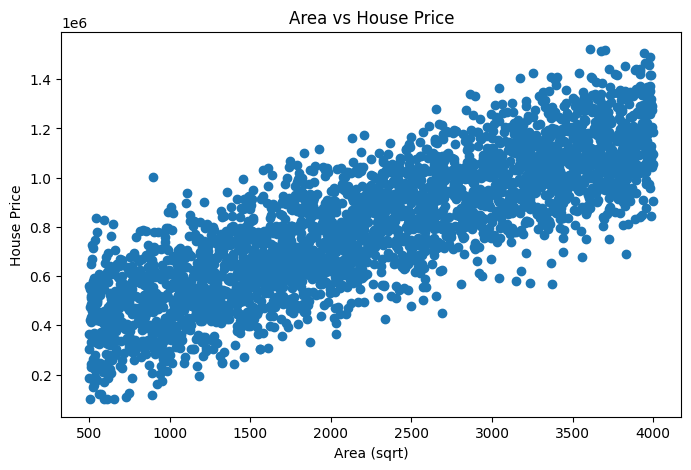

In [5]:
plt.figure(figsize=(8,5))
plt.scatter(df["Area_sqft"],df["Price"])
plt.xlabel("Area (sqrt)")
plt.ylabel("House Price")
plt.title("Area vs House Price")
plt.show()

In [6]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Area_sqft  Bedrooms  Bathrooms  House_Age_years  Parking_Spaces  Floor  \
0       3674         5          4                5               0     10   
1       1360         1          1                7               2     10   
2       1794         3          2               14               1      0   
3       1630         4          2               14               1      6   
4       1595         2          2               14               0      1   

   Distance_from_City_km  Location_Score  
0                    0.8               5  
1                    2.6               4  
2                    7.6               1  
3                   11.8              10  
4                    4.3               3  

Target:
0    1206454
1     582795
2     405058
3     877500
4     587633
Name: Price, dtype: int64


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2400, 8)
Testing data: (600, 8)


In [22]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE : 49224.87931261398
MSE : 3807504704.8577785
RMSE: 61704.981199719834
R2 Score: 0.9487510897297624


In [18]:
result = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print(result.head(10))

   Actual Price  Predicted Price
0       1366707     1.435469e+06
1        668047     6.296436e+05
2       1299940     1.275567e+06
3        784783     6.939900e+05
4       1027094     1.066761e+06
5        371687     3.606032e+05
6        557755     5.911192e+05
7        352496     4.069772e+05
8       1082600     1.027607e+06
9       1166260     1.125944e+06


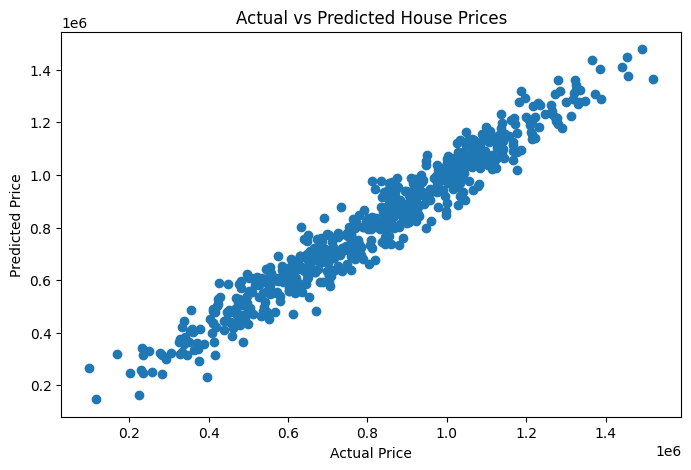

In [19]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")

plt.show()

In [20]:
new_house = pd.DataFrame({
    "Area_sqft": [1500],
    "Bedrooms": [3],
    "Bathrooms": [2],
    "House_Age_years": [5],
    "Parking_Spaces": [1],
    "Floor": [3],
    "Distance_from_City_km": [5],
    "Location_Score": [8]
})

predicted_price = model.predict(new_house)

print("Predicted House Price: ₹", round(predicted_price[0], 2))

Predicted House Price: ₹ 849366.18


In [21]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)
print("Random Forest MAE:", rf_mae)

Random Forest R2 Score: 0.929849550205299
Random Forest MAE: 56267.18095833334
